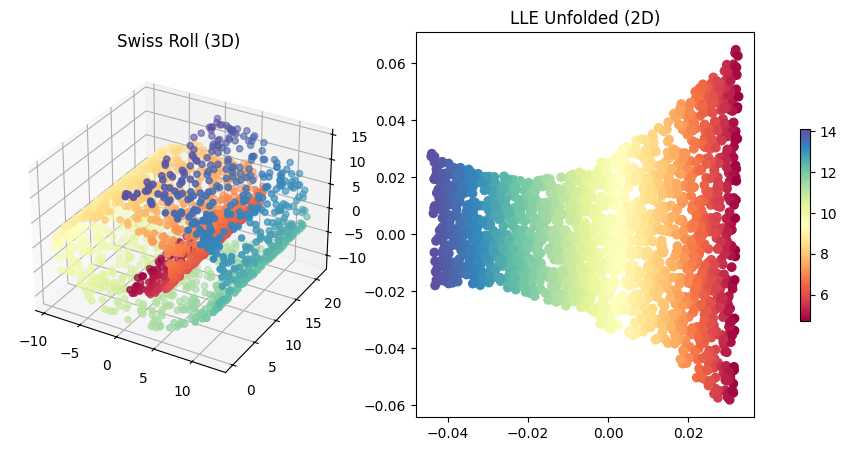

In [10]:
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
import matplotlib.pyplot as plt

# Step 1: Create Swiss Roll dataset (high-dimensional, 3D)
N = 2000
X, t = make_swiss_roll(n_samples=N, noise=0.05)

# Step 2: Apply LLE (reduce from 3D to 2D)
lle = LocallyLinearEmbedding(n_neighbors=12, n_components=2, method='standard')
Y = lle.fit_transform(X)

# Step 3: Plot results
fig = plt.figure(figsize=(12, 5))

# Original Swiss Roll (3D)
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.Spectral)
ax.set_title("Swiss Roll (3D)")

# LLE Embedding (2D unfolded)
ax2 = fig.add_subplot(122)
sc = ax2.scatter(Y[:, 0], Y[:, 1], c=t, cmap=plt.cm.Spectral)
ax2.set_title("LLE Unfolded (2D)")

plt.colorbar(sc, ax=[ax, ax2], shrink=0.5)
plt.show()

In [35]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
class LLE:
  def __init__(self, n_neighbors, n_components, method,reg):
    self.n_neighbors = n_neighbors
    self.n_components = n_components
    self.method = method
    self.reg=reg
  def compute(self, X):
    m=X.shape[0]
    W=np.zeros((m,m))

    # Step 1: Find nearest neighbors
    neighbors= NearestNeighbors(n_neighbors=self.n_neighbors+1).fit(X)
    distances , indices = neighbors.kneighbors(X)

    #step2 colve for weights
    for i in range(m):
      neighbors=indices[i,1:] # exclude itself
      Xi= X[neighbors]-X[i] #difference from neighbors

      #covariance matrix
      C= Xi@Xi.T
      C += np.eye(self.n_neighbors) * self.reg * np.trace(C)  # regularization

      # Solve for weights
      ones = np.ones(self.n_neighbors)
      w = np.linalg.solve(C, ones)
      w /= w.sum()                      # normalize weights

      W[i, neighbors] = w
    return W



  def fit_transform(self, X):
    W=self.compute(X)
    m=X.shape[0]
    #build M
    I=np.eye(m)
    M=(I-W).T@(I-W)
    #get eigenvectors
    eigvals,eigvecs=np.linalg.eigh(M)
    #sort eigenvalues and get corresponding indices
    sorted_indices= np.argsort(eigvals)

    embedding_indices=sorted_indices[1:self.n_components+1]
    Y=eigvecs[:,embedding_indices]

    return Y


i dont understand how the reg just flips the swiss roll have to understand this better

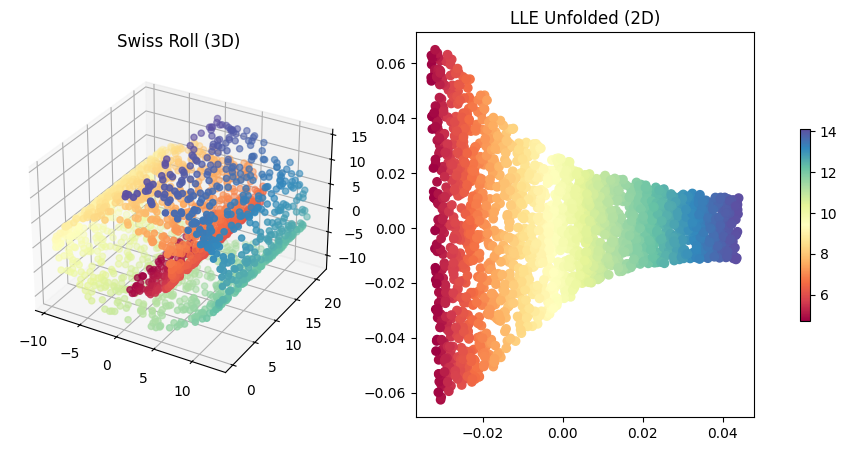

In [42]:
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding
import matplotlib.pyplot as plt



# Step 2: Apply LLE (reduce from 3D to 2D)
lle = LLE(n_neighbors=15, n_components=2, method='standard', reg=1e-3)
Y = lle.fit_transform(X)

# Step 3: Plot results
fig = plt.figure(figsize=(12, 5))

# Original Swiss Roll (3D)
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.Spectral)
ax.set_title("Swiss Roll (3D)")

# LLE Embedding (2D unfolded)
ax2 = fig.add_subplot(122)
sc = ax2.scatter(Y[:, 0], Y[:, 1], c=t, cmap=plt.cm.Spectral)
ax2.set_title("LLE Unfolded (2D)")

plt.colorbar(sc, ax=[ax, ax2], shrink=0.5)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


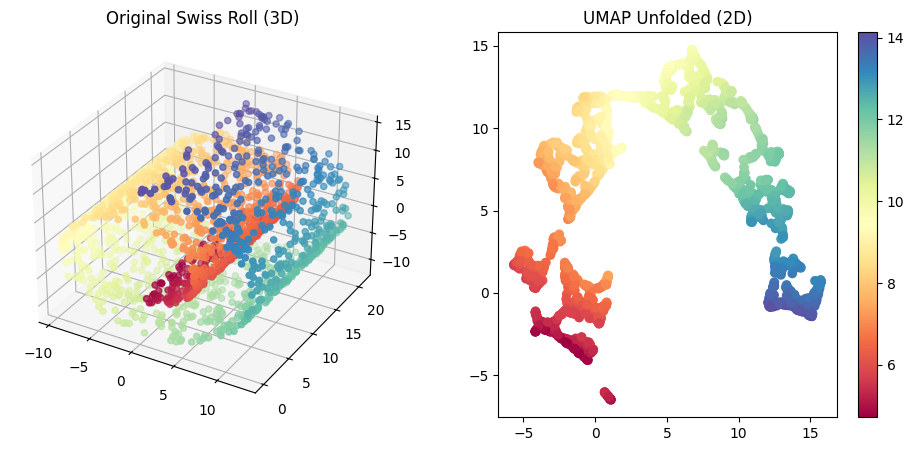

In [45]:
import numpy as np
from sklearn.datasets import make_swiss_roll
import umap
import matplotlib.pyplot as plt


# Run UMAP (2D embedding)
umap_model = umap.UMAP(n_neighbors=15, n_components=2, random_state=42)
Y = umap_model.fit_transform(X)

# Plot original 3D Swiss roll
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(121, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.Spectral)
ax.set_title("Original Swiss Roll (3D)")

# Plot UMAP embedding
ax2 = fig.add_subplot(122)
sc = ax2.scatter(Y[:, 0], Y[:, 1], c=t, cmap=plt.cm.Spectral)
ax2.set_title("UMAP Unfolded (2D)")
plt.colorbar(sc, ax=ax2)

plt.show()

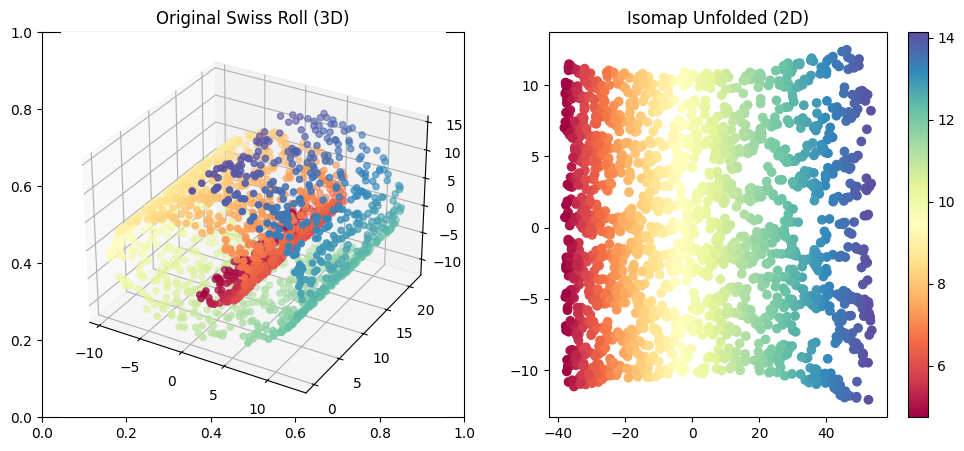

In [47]:
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt

# Generate Swiss roll
X, t = make_swiss_roll(n_samples=2000, noise=0.05, random_state=42)

# Isomap embedding
isomap = Isomap(n_neighbors=12, n_components=2)
Y = isomap.fit_transform(X)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.Spectral)
ax1.set_title("Original Swiss Roll (3D)")

sc = ax2.scatter(Y[:, 0], Y[:, 1], c=t, cmap=plt.cm.Spectral)
ax2.set_title("Isomap Unfolded (2D)")
plt.colorbar(sc, ax=ax2)

plt.show()